In [2]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
path = os.path.join(os.getcwd(), '..', 'data' ,'cleaned', 'cleaned_data.parquet')
df = pd.read_parquet(path)

In [4]:
df.shape

(1787451, 9)

In [5]:
df.head()

,Date,Open,High,Low,Close,Volume,Stock,Sector,Industry
0,2010-01-04,19.948868,20.101393,19.783634,19.891672,3815561.0,A,Health Care,Life Sciences Tools & Services
1,2010-01-05,19.834483,19.840838,19.548500,19.675604,4186031.0,A,Health Care,Life Sciences Tools & Services
2,2010-01-06,19.605696,19.701023,19.548498,19.605696,3243779.0,A,Health Care,Life Sciences Tools & Services
3,2010-01-07,19.561205,19.586627,19.383262,19.580273,3095172.0,A,Health Care,Life Sciences Tools & Services
4,2010-01-08,19.472235,19.605694,19.319712,19.573917,3733918.0,A,Health Care,Life Sciences Tools & Services


In [33]:
print(df['Stock'].nunique(), "stocks")
print(df['Date'].min(), "→", df['Date'].max())
df.groupby('Stock')['Date'].agg(['min', 'max', 'count']).head()

503 stocks
2010-01-04 00:00:00 → 2024-12-31 00:00:00


,min,max,count
Stock,,,
A,2010-01-04,2024-12-31,3774
AAPL,2010-01-04,2024-12-31,3774
ABBV,2013-01-02,2024-12-31,3020
ABNB,2020-12-10,2024-12-31,1020
ABT,2010-01-04,2024-12-31,3774


<Axes: >

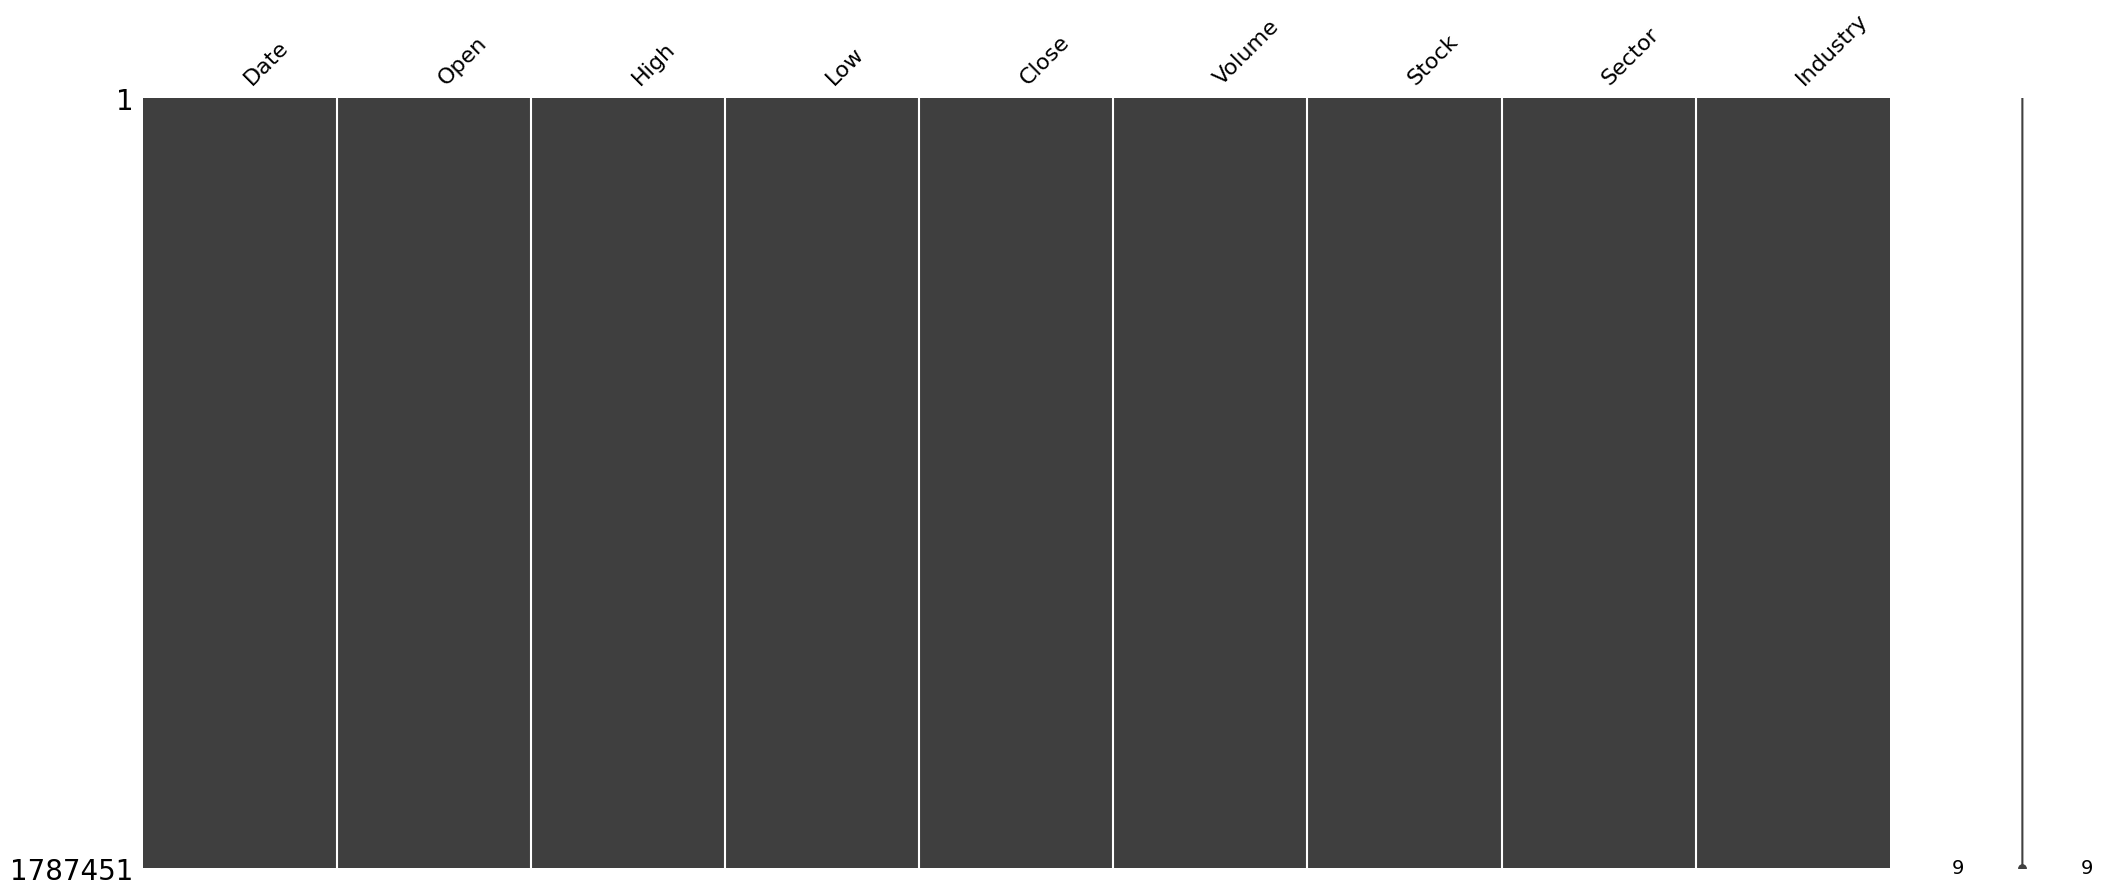

In [7]:
import missingno as msno

msno.matrix(df.sort_values('Date'))

In [8]:
summary = df.groupby('Stock')[['Open','High','Low','Close','Volume']].describe().transpose()
summary.head()

Stock                 A         AAPL         ABBV         ABNB          ABT  \
Open count  3774.000000  3774.000000  3020.000000  1020.000000  3774.000000   
     mean     68.565818    67.300775    77.485588   139.888001    58.287394   
     std      43.627583    65.363842    44.353321    26.139955    34.621071   
     min      17.178017     5.774969    19.999912    82.970001    15.621153   
     25%      32.494276    17.422621    41.517534   119.356249    29.144841   

Stock              ACGL          ACN         ADBE          ADI          ADM  \
Open count  3774.000000  3774.000000  3774.000000  3774.000000  3774.000000   
     mean     32.030171   149.711798   227.177650    86.110848    39.008563   
     std      22.646226   102.489480   194.932994    58.500000    17.700946   
     min       7.358898    27.532263    22.969999    18.387802    16.210081   
     25%      17.140738    62.734122    51.687500    37.121029    25.840637   

Stock       ...           WY         WYNN          XEL          XOM  \
Open count  ...  3774.000000  3774.000000  3774.000000  3774.000000   
     mean   ...    22.000287   100.796958    37.148664    60.130965   
     std    ...     6.837828    31.764082    17.776089    20.854166   
     min    ...     7.406842    39.134726    11.689131    25.192715   
     25%    ...    18.121840    81.224992    19.488297    49.309967   

Stock               XYL          XYZ          YUM          ZBH         ZBRA  \
Open count  3325.000000  2293.000000  3774.000000  3774.000000  3774.000000   
     mean     64.129767    81.988854    70.822929    97.455838   170.472946   
     std      34.466222    66.194793    35.476239    29.583181   145.365612   
     min      19.385710     8.270000    17.548529    40.076764    24.340000   
     25%      31.845126    44.180000    40.868936    73.666434    47.290000   

Stock               ZTS  
Open count  2999.000000  
     mean    102.447089  
     std      59.978544  
     min      26.059690  
     25%      43.818935  

[5 rows x 503 columns]

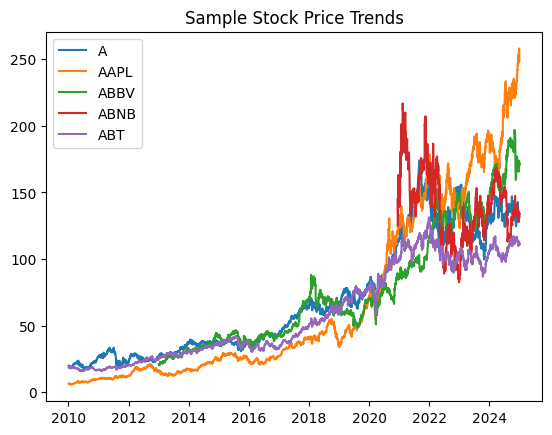

In [9]:
sample_stocks = df['Stock'].unique()[:5]
for stock in sample_stocks:
    temp = df[df['Stock'] == stock]
    plt.plot(temp['Date'], temp['Close'], label=stock)
plt.legend()
plt.title("Sample Stock Price Trends")
plt.show()


In [10]:
df['Daily_Return'] = df.groupby('Stock')['Close'].pct_change()
df['Daily_Return'].describe()

count    1.786948e+06
mean     7.205835e-04
std      1.977685e-02
min     -5.386473e-01
25%     -7.999820e-03
50%      7.391085e-04
75%      9.510595e-03
max      7.459324e-01
Name: Daily_Return, dtype: float64

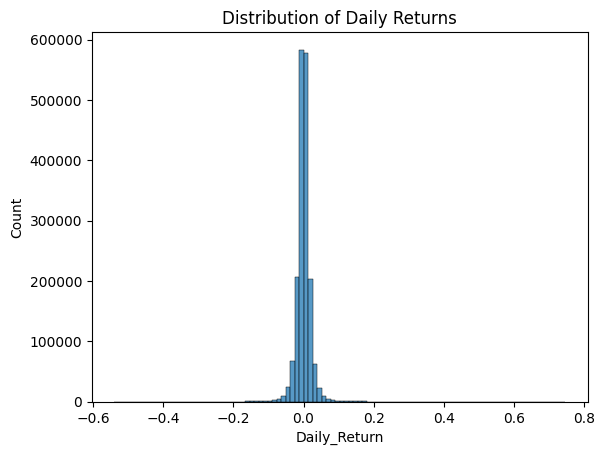

In [11]:
import seaborn as sns

sns.histplot(df['Daily_Return'].dropna(), bins=100)
plt.title("Distribution of Daily Returns")
plt.show()


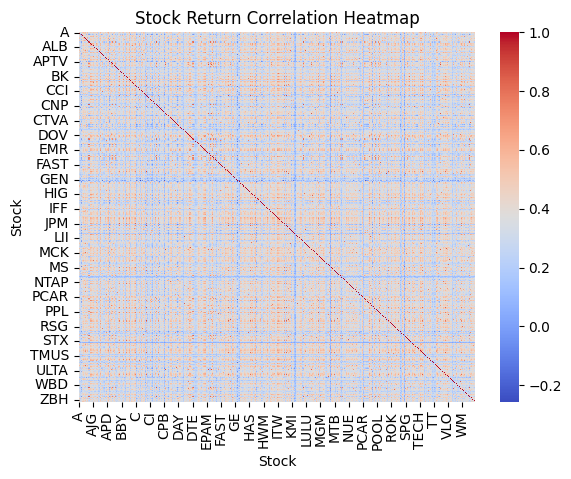

In [12]:
pivot_returns = df.pivot(index='Date', columns='Stock', values='Daily_Return')
corr_matrix = pivot_returns.corr()
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Stock Return Correlation Heatmap")
plt.show()

In [13]:
corr_matrix = pivot_returns.corr()
corr_unstacked = corr_matrix.unstack().drop_duplicates()
sorted_corr = corr_unstacked.sort_values()

print("Most positively correlated pairs:\n", sorted_corr.tail(10))
print("\nMost negatively correlated pairs:\n", sorted_corr.head(10))

Most positively correlated pairs:
 Stock  Stock
CFG    FITB     0.893927
       KEY      0.894575
MET    PRU      0.896559
FRT    REG      0.898477
EQR    UDR      0.904819
AVB    EQR      0.910415
NWS    NWSA     0.972820
FOX    FOXA     0.987616
GOOG   GOOGL    0.995413
A      A        1.000000
dtype: float64

Most negatively correlated pairs:
 Stock  Stock
CBOE   GEV     -0.256789
CPB    GEV     -0.223899
GEV    GIS     -0.216316
       PEP     -0.208507
       JNJ     -0.201420
       KO      -0.165430
       TSN     -0.160487
CAG    GEV     -0.152815
DXCM   GEV     -0.148503
AMT    GEV     -0.145876
dtype: float64


In [30]:
df['Market_Return'] = df.groupby('Date')['Daily_Return'].transform('mean')
corrs = df.groupby('Stock').apply(lambda x: x['Daily_Return'].corr(x['Market_Return']))
corrs.sort_values(ascending=False).head(10)

Stock
AMP      0.832642
HON      0.812413
PFG      0.806435
PRU      0.805886
TROW     0.805044
PH       0.804588
BLK      0.802212
AME      0.801899
ITW      0.799554
BRK-B    0.795466
dtype: float64

In [31]:
df['Market_Return'] = df.groupby('Date')['Daily_Return'].transform('mean')
corrs = df.groupby('Stock').apply(lambda x: x['Daily_Return'].corr(x['Market_Return']))
corrs.sort_values(ascending=True).head(10)

Stock
SW      0.139591
MRNA    0.165328
NEM     0.227173
SOLV    0.274340
KVUE    0.279024
KR      0.285019
CPB     0.287209
PCG     0.292384
CLX     0.293079
K       0.333493
dtype: float64

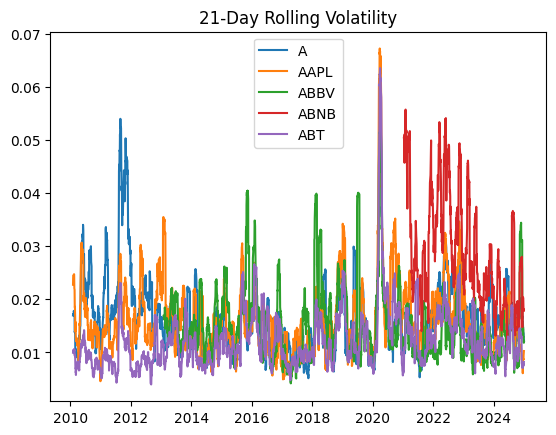

In [15]:
df['Rolling_Volatility'] = df.groupby('Stock')['Daily_Return'].rolling(window=21).std().reset_index(0, drop=True)

import matplotlib.pyplot as plt
for stock in df['Stock'].unique()[:5]:
    temp = df[df['Stock'] == stock]
    plt.plot(temp['Date'], temp['Rolling_Volatility'], label=stock)
plt.legend()
plt.title("21-Day Rolling Volatility")
plt.show()


In [16]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Stock', 'Sector',
       'Industry', 'Daily_Return', 'Market_Return', 'Rolling_Volatility'],
      dtype='object')

In [17]:
import pandas as pd

sector_df = (
    df.groupby(['Date', 'Sector'])
    .agg({
        'Close': 'mean',
        'Volume': 'mean',
        'Daily_Return': 'mean'
    })
    .reset_index()
)

# Optional: Add rolling averages to smooth noise
sector_df['Sector_Return_7d'] = sector_df.groupby('Sector')['Daily_Return'].transform(lambda x: x.rolling(7).mean())
sector_df.head()


,Date,Sector,Close,Volume,Daily_Return,Sector_Return_7d
0,2010-01-04,Communication Services,12.586578,1.775572e+07,NaN,NaN
1,2010-01-04,Consumer Discretionary,41.578821,1.193413e+07,NaN,NaN
2,2010-01-04,Consumer Staples,21.293960,5.830440e+06,NaN,NaN
3,2010-01-04,Energy,29.570390,7.480764e+06,NaN,NaN
4,2010-01-04,Financials,26.282040,9.089111e+06,NaN,NaN


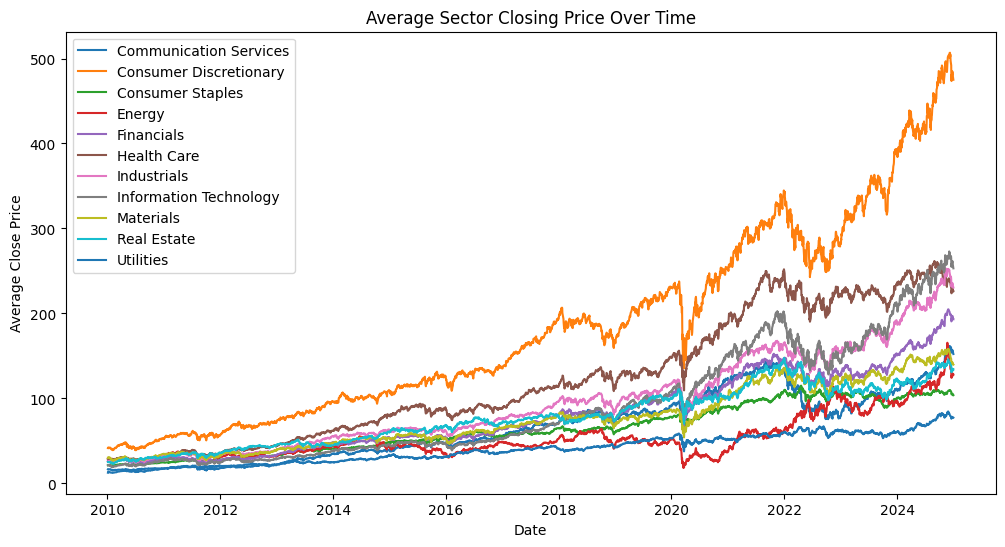

In [18]:
plt.figure(figsize=(12, 6))
for sector in sector_df['Sector'].unique():
    temp = sector_df[sector_df['Sector'] == sector]
    plt.plot(temp['Date'], temp['Close'], label=sector)

plt.title('Average Sector Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Average Close Price')
plt.legend()
plt.show()


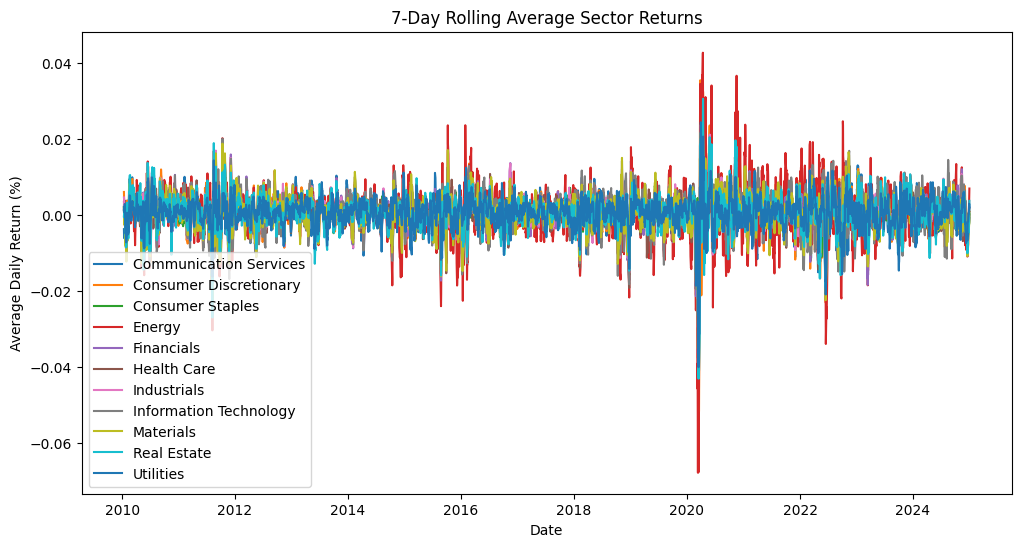

In [19]:
plt.figure(figsize=(12, 6))
for sector in sector_df['Sector'].unique():
    temp = sector_df[sector_df['Sector'] == sector]
    plt.plot(temp['Date'], temp['Sector_Return_7d'], label=sector)

plt.title('7-Day Rolling Average Sector Returns')
plt.xlabel('Date')
plt.ylabel('Average Daily Return (%)')
plt.legend()
plt.show()


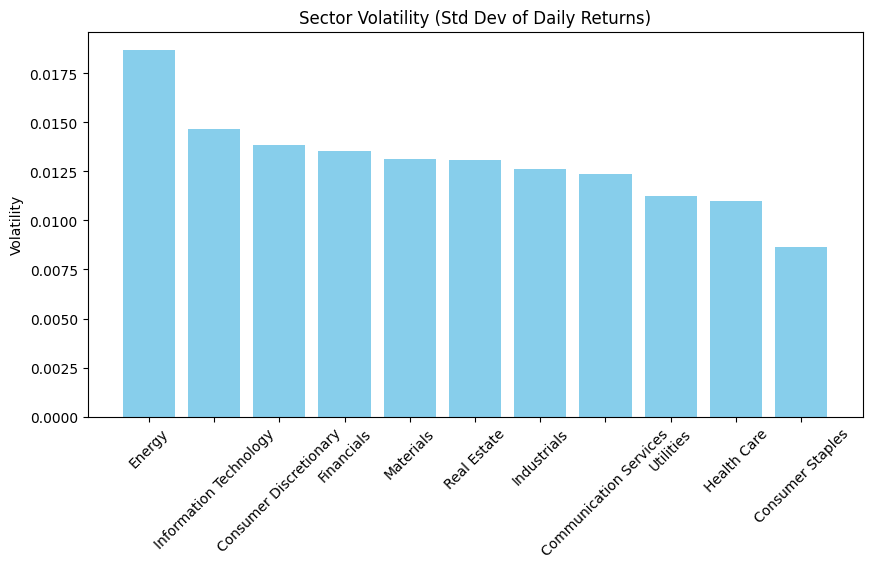

In [20]:
volatility = (
    sector_df.groupby('Sector')['Daily_Return']
    .std()
    .sort_values(ascending=False)
    .reset_index()
)
plt.figure(figsize=(10, 5))
plt.bar(volatility['Sector'], volatility['Daily_Return'], color='skyblue')
plt.xticks(rotation=45)
plt.title('Sector Volatility (Std Dev of Daily Returns)')
plt.ylabel('Volatility')
plt.show()

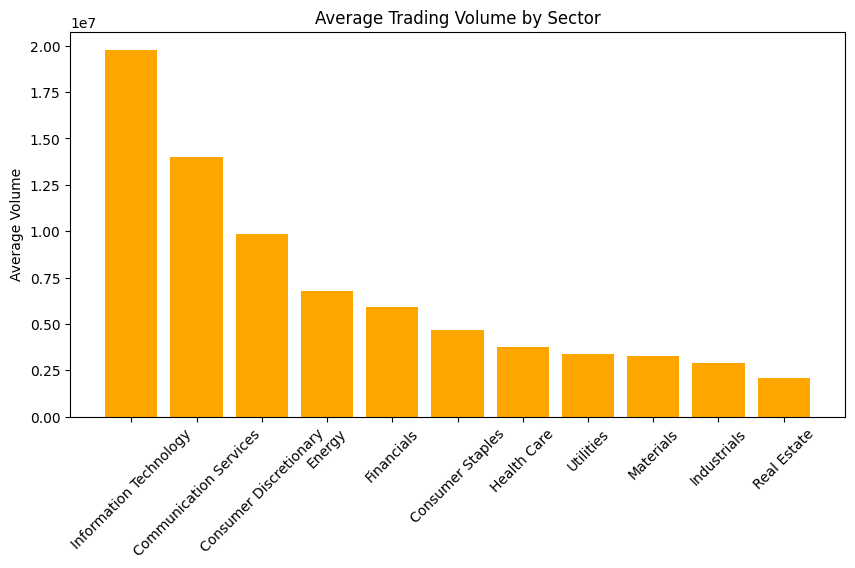

In [21]:
avg_volume = sector_df.groupby('Sector')['Volume'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
plt.bar(avg_volume.index, avg_volume.values, color='orange')
plt.title('Average Trading Volume by Sector')
plt.ylabel('Average Volume')
plt.xticks(rotation=45)
plt.show()

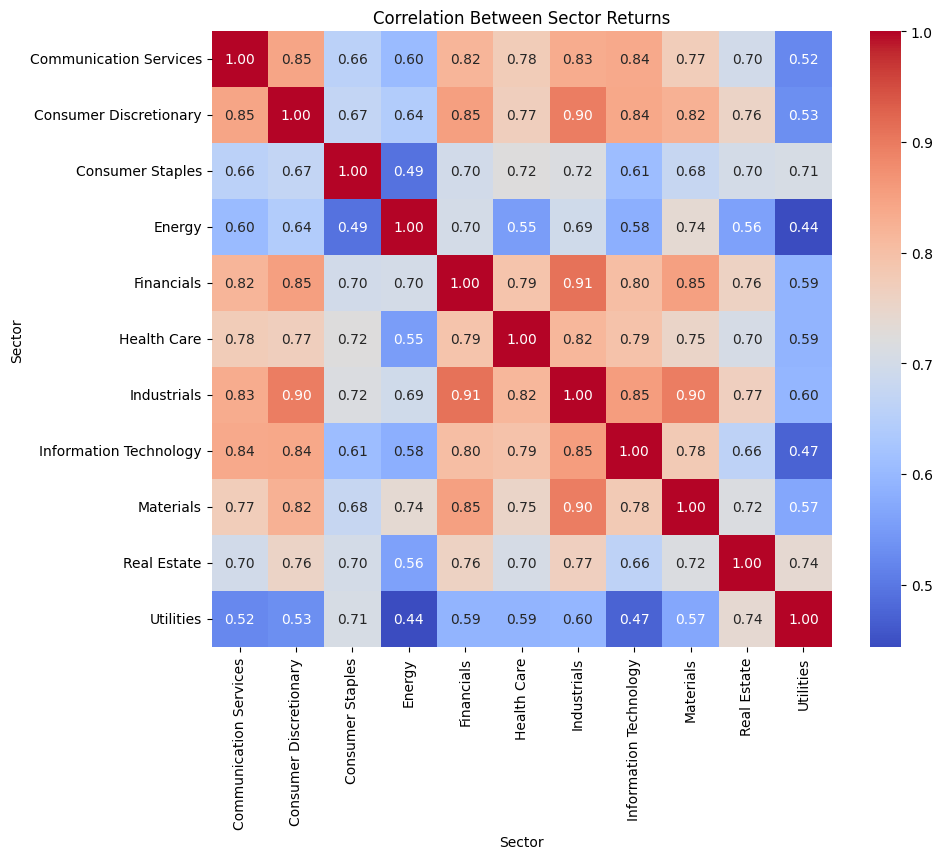

In [22]:
corr_df = sector_df.pivot(index='Date', columns='Sector', values='Daily_Return')
corr_matrix = corr_df.corr()

plt.figure(figsize=(10, 8))
import seaborn as sns
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Sector Returns')
plt.show()


In [23]:
sector_perf = (
    sector_df.groupby('Sector')['Daily_Return']
    .apply(lambda x: (1 + x.fillna(0)).prod() - 1)
    .sort_values(ascending=False)
)
print("Cumulative Return by Sector (2010–2025):")
print(sector_perf)


Cumulative Return by Sector (2010–2025):
Sector
Information Technology    22.038063
Consumer Discretionary    15.738386
Communication Services    13.072095
Industrials               12.911366
Health Care               10.313746
Financials                 8.959695
Materials                  5.922673
Real Estate                5.265365
Energy                     5.250239
Consumer Staples           4.897830
Utilities                  4.546830
Name: Daily_Return, dtype: float64


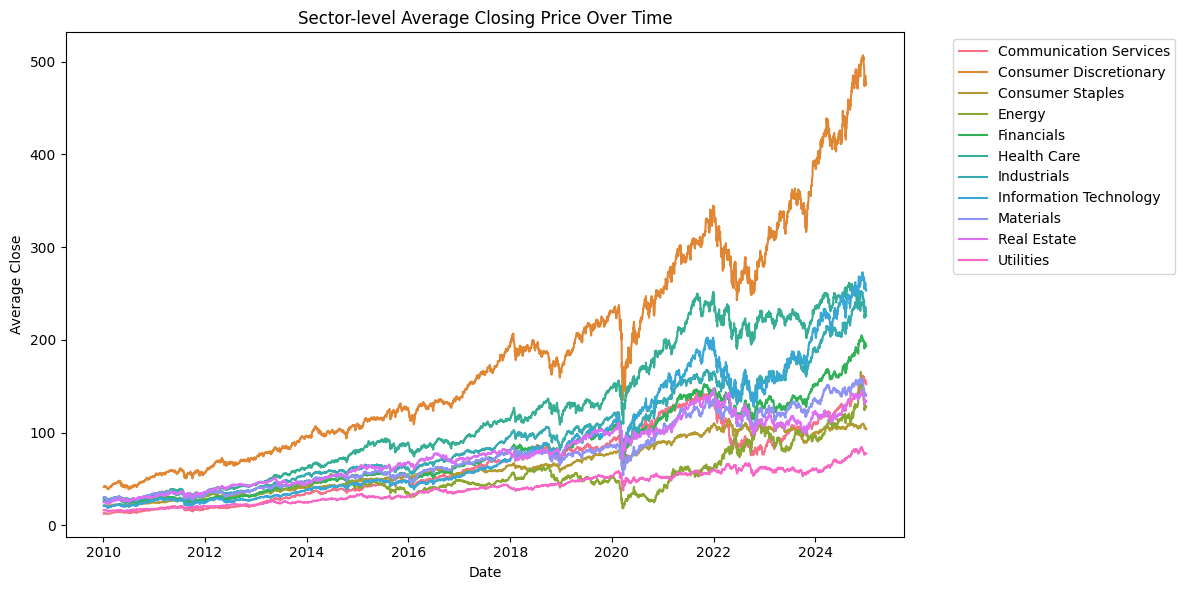

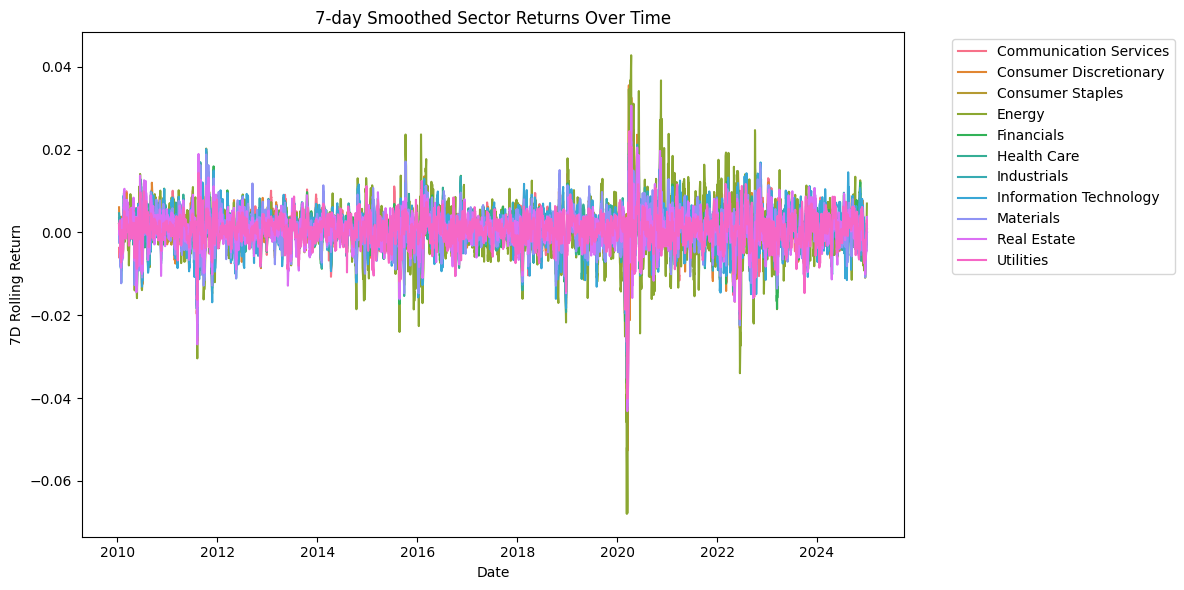

In [24]:
plt.figure(figsize=(12,6))
sns.lineplot(data=sector_df, x='Date', y='Close', hue='Sector')
plt.title('Sector-level Average Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Average Close')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 7-day smoothed returns
plt.figure(figsize=(12,6))
sns.lineplot(data=sector_df, x='Date', y='Sector_Return_7d', hue='Sector')
plt.title('7-day Smoothed Sector Returns Over Time')
plt.xlabel('Date')
plt.ylabel('7D Rolling Return')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


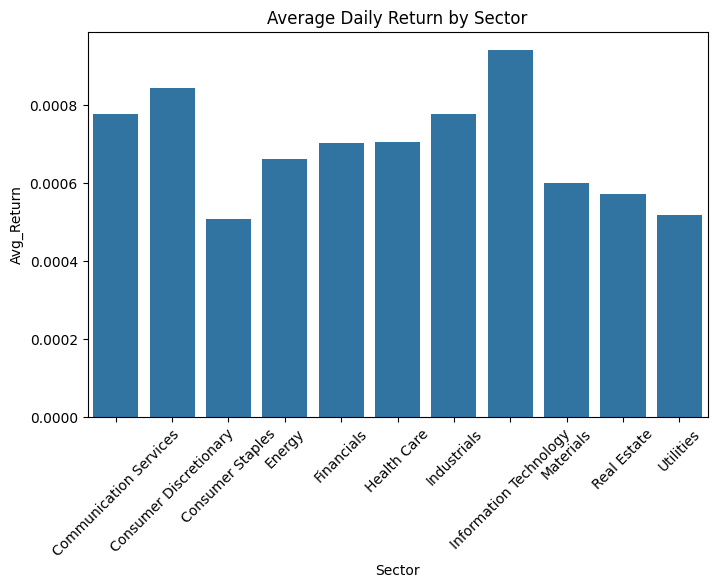

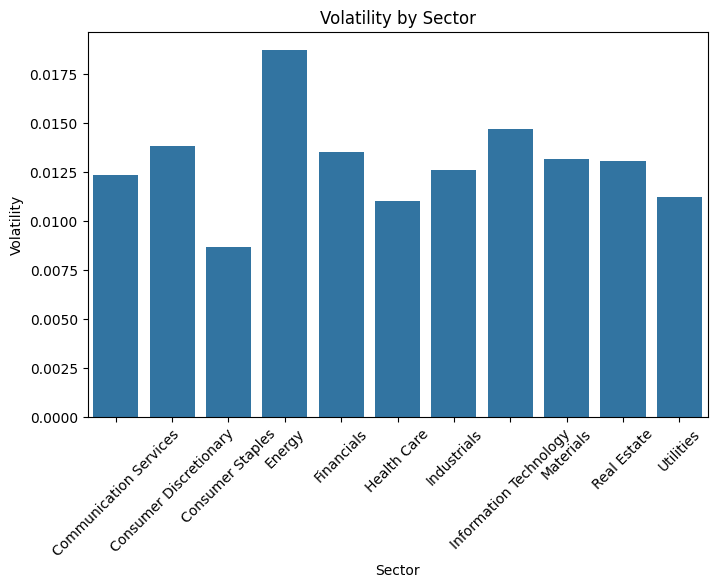

,Sector,Avg_Return,Volatility
7,Information Technology,0.000940,0.014677
1,Consumer Discretionary,0.000843,0.013833
6,Industrials,0.000778,0.012603
0,Communication Services,0.000778,0.012347
5,Health Care,0.000704,0.011007
4,Financials,0.000701,0.013528
3,Energy,0.000662,0.018696
8,Materials,0.000600,0.013140
9,Real Estate,0.000573,0.013075
10,Utilities,0.000517,0.011237


In [25]:
sector_stats = (
    sector_df.groupby('Sector')['Daily_Return']
    .agg(['mean', 'std'])
    .rename(columns={'mean': 'Avg_Return', 'std': 'Volatility'})
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(data=sector_stats, x='Sector', y='Avg_Return')
plt.title('Average Daily Return by Sector')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=sector_stats, x='Sector', y='Volatility')
plt.title('Volatility by Sector')
plt.xticks(rotation=45)
plt.show()

sector_stats.sort_values('Avg_Return', ascending=False)


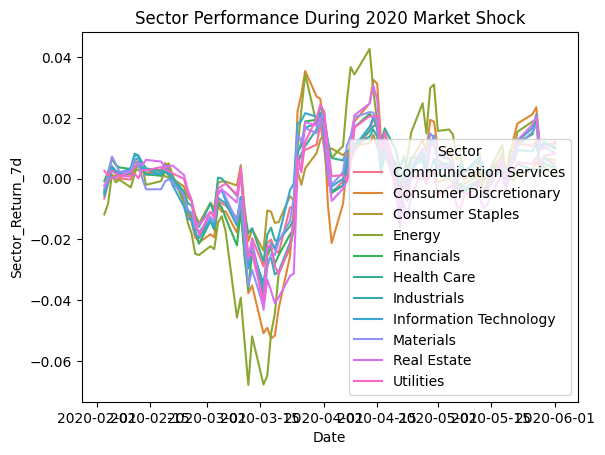

In [26]:
crisis = sector_df[(sector_df['Date'] >= '2020-02-01') & (sector_df['Date'] <= '2020-06-01')]
sns.lineplot(data=crisis, x='Date', y='Sector_Return_7d', hue='Sector')
plt.title('Sector Performance During 2020 Market Shock')
plt.show()

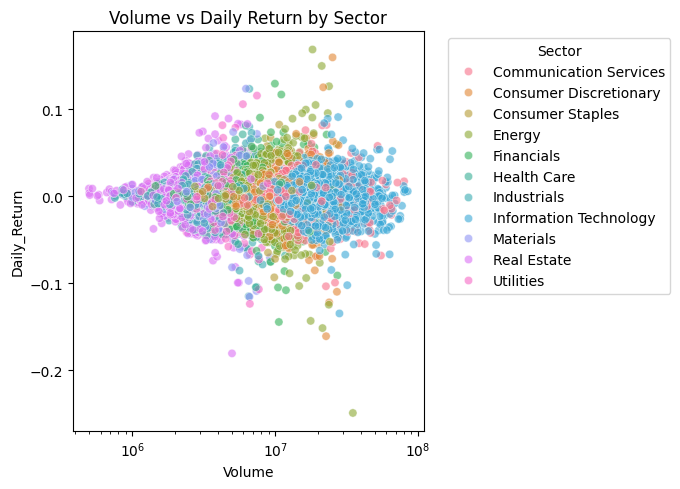

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=sector_df, x='Volume', y='Daily_Return', hue='Sector', alpha=0.6)
plt.title('Volume vs Daily Return by Sector')
plt.xscale('log')
plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
